# **Experiment #5 batch size | Results**

## Setup

Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import networkx as nx
import itertools
from collections import defaultdict

import sys
sys.path.append("../..")

from models.KGIL.utils.metrics import (
    levenshtein_distance,
    calc_cosine_similarity_fixed, 
    gini_coefficient
)
from utils.data_processing import Visualize_KG, KG_Filter, Process_KG

Parameters

## Quantitive Performance
### Prediction ranking metrics

In [2]:
DATASET = "amazon-Video_Games"
EXPERIMENT_NAME = "#5 Keyword Batch size"
MODEL_TECHNIQUE_NAME = "gemma3"

current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

BATCH_SIZES = ["5","15"]
REDUNDANCY_STRATEGY = "wo-grand-parents"
N_HOPS = ["3","6","9","11"]

relevant_metrics = ["NDCG@20","Recall@20"]
relevant_metrics_df = pd.DataFrame()
metrics_df = pd.DataFrame()
for BATCH_SIZE in BATCH_SIZES:
    METRICS_PATH = os.path.join(project_root, 'data','experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE_NAME,REDUNDANCY_STRATEGY,BATCH_SIZE)
    for N_HOP in N_HOPS:
        n_hops_metrics_df = pd.read_csv(f"{METRICS_PATH}/{N_HOP}-hops_acc_df.csv")
        n_hops_metrics_df["batch_size"] = BATCH_SIZE
        n_hops_metrics_df["n_hops"] = N_HOP
        metrics_df = pd.concat([metrics_df, n_hops_metrics_df], ignore_index=True)

        for METRIC in relevant_metrics:
            temp_df = metrics_df[metrics_df["Metric"] == METRIC]
            relevant_metrics_df = pd.concat([relevant_metrics_df, temp_df], ignore_index=True)
        


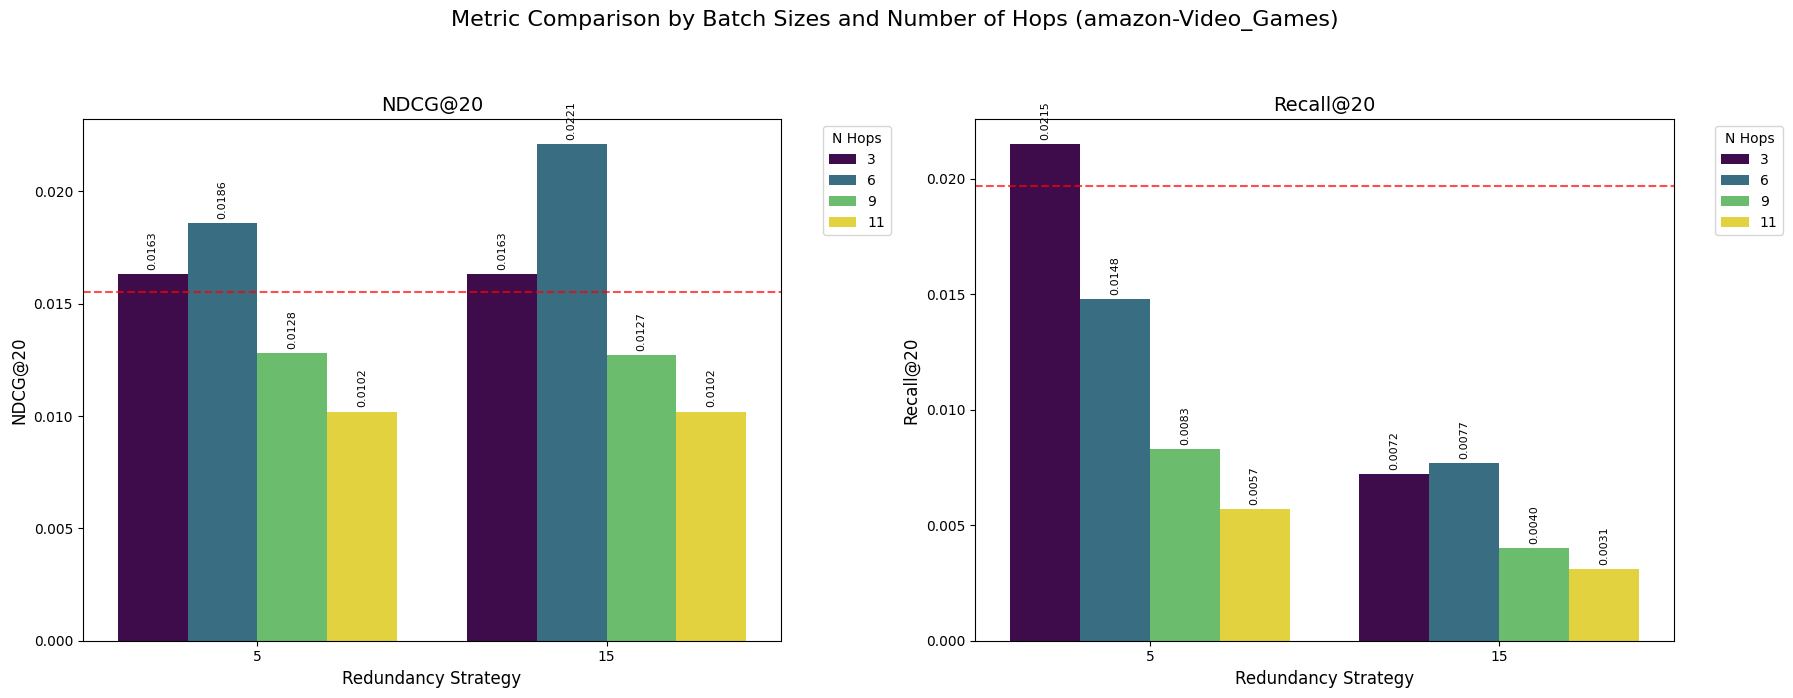

In [3]:
# Ensure n_hops is numeric for sorting and plotting
relevant_metrics_df['n_hops'] = pd.to_numeric(relevant_metrics_df['n_hops'])

# Get unique redundancy strategies and sorted n_hops
batch_size = relevant_metrics_df['batch_size'].unique()
n_hops_order = sorted(relevant_metrics_df['n_hops'].unique())

# Create subplots: one row, two columns (Hit Ratio, Precision)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7)) # Adjusted figsize for better group display

fig.suptitle(f'Metric Comparison by Batch Sizes and Number of Hops ({DATASET})', fontsize=16, y=1.02) # Adjust y for suptitle

# --- Subplot 1: Hit Ratio @ 20 ---
ax1 = axes[0]
# Filter for the specific metric
hr_df = relevant_metrics_df[relevant_metrics_df['Metric'] == 'NDCG@20']
# Plot grouped barplot: x=strategy, hue=n_hops
sns.barplot(data=hr_df, x='batch_size', y='Value', hue='n_hops', ax=ax1, palette='viridis', hue_order=n_hops_order)
ax1.set_xlabel('Redundancy Strategy', fontsize=12)
ax1.set_ylabel('NDCG@20', fontsize=12)
ax1.set_title('NDCG@20', fontsize=14)
ax1.tick_params(axis='x', rotation=0, labelsize=10)
ax1.tick_params(axis='y', labelsize=10)
ax1.legend(title='N Hops', bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position

# Add red horizontal line at 0.0155 for NDCG
ax1.axhline(y=0.0155, color='red', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.4f', fontsize=8, padding=3, rotation=90) # Rotate labels if needed

# --- Subplot 2: Precision @ 20 ---
ax2 = axes[1]
# Filter for the specific metric
pr_df = relevant_metrics_df[relevant_metrics_df['Metric'] == 'Recall@20']
# Plot grouped barplot: x=strategy, hue=n_hops
sns.barplot(data=pr_df, x='batch_size', y='Value', hue='n_hops', ax=ax2, palette='viridis', hue_order=n_hops_order)
ax2.set_xlabel('Redundancy Strategy', fontsize=12)
ax2.set_ylabel('Recall@20', fontsize=12)
ax2.set_title('Recall@20', fontsize=14)
ax2.tick_params(axis='x', rotation=0, labelsize=10)
ax2.tick_params(axis='y', labelsize=10)
ax2.legend(title='N Hops', bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position

# Add red horizontal line at 0.0197 for Recall
ax2.axhline(y=0.0197, color='red', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.4f', fontsize=8, padding=3, rotation=90) # Rotate labels if needed

# Adjust layout to prevent titles/labels overlapping
fig.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust rect to make space for suptitle

plt.show()

# Resetting figure size here affects subsequent plots, not the one just shown.
# Consider setting rcParams before creating the plot if a default size is desired for this specific plot.
plt.rcParams['figure.figsize'] = [18, 10] # Example: Set default for future plots


In [4]:
# Load results for baseline (with-redundancy) and wo-grand-parents for threshold 0.7 and 3 hops
TRESHOLD = "085"
N_HOPS_TRESHOLD ="6"
EXPERIMENT_4_PATH = os.path.join(project_root, 'data','experiments',"#4 Linking Hyperparameter treshhold",DATASET,MODEL_TECHNIQUE_NAME,"wo-grand-parents",TRESHOLD)
BATCH_SIZE = "5"
EXPERIMENT_5_PATH = os.path.join(project_root, 'data','experiments',"#5 Keyword Batch size",DATASET, MODEL_TECHNIQUE_NAME,"wo-grand-parents",BATCH_SIZE)
N_HOPS_BATCH_SIZE = "3"

batch_size_5_metrics = pd.read_csv(f"{EXPERIMENT_5_PATH}/{N_HOPS_BATCH_SIZE}-Hops_acc_df.csv")
baseline_metrics = pd.read_csv(f"{EXPERIMENT_4_PATH}/{N_HOPS_TRESHOLD}-Hops_acc_df.csv")

# Get baseline metrics
baseline_ndcg = baseline_metrics[baseline_metrics['Metric'] == 'NDCG@20']['Value'].iloc[0]
baseline_recall = baseline_metrics[baseline_metrics['Metric'] == 'Recall@20']['Value'].iloc[0]
baseline_hit_ratio = baseline_metrics[baseline_metrics['Metric'] == 'Hit_Ratio@20']['Value'].iloc[0]
baseline_precision = baseline_metrics[baseline_metrics['Metric'] == 'Precision@20']['Value'].iloc[0]

# Get wo-grand-parents metrics
wo_gp_ndcg = batch_size_5_metrics[batch_size_5_metrics['Metric'] == 'NDCG@20']['Value'].iloc[0]
wo_gp_recall = batch_size_5_metrics[batch_size_5_metrics['Metric'] == 'Recall@20']['Value'].iloc[0]
wo_gp_hit_ratio = batch_size_5_metrics[batch_size_5_metrics['Metric'] == 'Hit_Ratio@20']['Value'].iloc[0]
wo_gp_precision = batch_size_5_metrics[batch_size_5_metrics['Metric'] == 'Precision@20']['Value'].iloc[0]

# Calculate percentage changes
ndcg_delta = ((wo_gp_ndcg - baseline_ndcg) / baseline_ndcg) * 100
recall_delta = ((wo_gp_recall - baseline_recall) / baseline_recall) * 100
hit_ratio_delta = ((wo_gp_hit_ratio - baseline_hit_ratio) / baseline_hit_ratio) * 100
precision_delta = ((wo_gp_precision - baseline_precision) / baseline_precision) * 100

# Print results
print("\nResults for wo-grand-parents vs baseline (batch_size=5, n_hops=3):")
print(f"NDCG@20: {wo_gp_ndcg:.4f} (baseline: {baseline_ndcg:.4f}, delta: {ndcg_delta:+.2f}%)")
print(f"Recall@20: {wo_gp_recall:.4f} (baseline: {baseline_recall:.4f}, delta: {recall_delta:+.2f}%)")
print(f"Hit_Ratio@20: {wo_gp_hit_ratio:.4f} (baseline: {baseline_hit_ratio:.4f}, delta: {hit_ratio_delta:+.2f}%)")
print(f"Precision@20: {wo_gp_precision:.4f} (baseline: {baseline_precision:.4f}, delta: {precision_delta:+.2f}%)")




Results for wo-grand-parents vs baseline (batch_size=5, n_hops=3):
NDCG@20: 0.0163 (baseline: 0.0155, delta: +5.16%)
Recall@20: 0.0215 (baseline: 0.0197, delta: +9.14%)
Hit_Ratio@20: 0.0431 (baseline: 0.0394, delta: +9.39%)
Precision@20: 0.0022 (baseline: 0.0020, delta: +10.00%)


**General Trend:**

- The analysis of the prediction for the ranking metrics Recall@20 and NDCG@20 revealed mixed results. 
- For both batch sizes 5 and 15 some configurations of the gnn were able to beat the current baseline from llm-col-hierarchy-tax-wo-grand-parents-threshhold-85 for the `ndcg@20`
- For NDCG@20 the batch results was less impactful because for hops the results are partial identical or very close to it
- For Recall@20 we observe that the batch size of 5 was more impactful with all hop configuration being lot higher compared to the ones at 15

**Impact of Batch sizes on tracing**
- analysis of LLM behavior revealed that semantic drift and task goal deviation occurred exclusively in batch size 15 configurations, while batch size 5 maintained task alignment throughout the experiment. [(Ref. Tracing for batch size 5)](https://dagshub.com/jonas.limniatis2/LLM-Col.mlflow/#/experiments/7/runs/94fc5b557f6249c6abd49629bd93de2a/traces)
- Task goal degradation was observed in batch size 15 configurations during batch processing, indicating reduced taxonomy generation stability. [(Ref. Tracing for batch size 15)](https://dagshub.com/jonas.limniatis2/LLM-Col.mlflow/#/experiments/8/runs/03e4968a355d48ddb13fc944c68ab270)
- Analysis suggests that a context window of approximately 25 keywords plus taxonomy tokens per batch point represents the optimal configuration for minimizing hallucination and maintaining task goal adherence.
- This configuration demonstrates improved coverage metrics, as evidenced by the LLM's consistent consideration of all keywords during taxonomy generation.

**Batch Size Comparison Analysis:**

The analysis reveals several key insights about the impact of batch size on model performance:

1. **NDCG Performance:**
   - Both batch sizes (5 and 15) show equivalent NDCG scores across different hop counts
   - This suggests that batch size doesn't significantly impact the ranking quality of recommendations
   - batch size 5 and 15 at 3 and 6 hops manages to outperform the baseline, with 6 being highest

2. **Recall Performance:**
   - Batch size 5 consistently outperforms batch size 15 across all hop counts
   - Batch size 5 at 3 hops was only configuration to outperform baseline 
   - Batch size 15 for all configuration way under former baseline
   - This indicates that smaller batch sizes are more effective at retrieving relevant items
   - The superior recall performance of batch size 5 suggests better coverage of the recommendation space

3. **Optimal Configuration:**
   - The combination of batch size 5 with 3 hops emerges as the most effective configuration
   - This setup not only beats the baseline for both NDCG and Recall metrics
   - Suggests that smaller batch sizes with moderate hop counts provide the best balance between recommendation quality and coverage


### Confusion Matrix

No self-loops found in the taxonomy.
Identified 4661 redundant item-to-grandchild relationships to remove.
Original relations DataFrame size: 14436
Filtered relations DataFrame size: 9775
Processing Strategy: wo-grand-parents, Hops: 6
Accuracy in test set: 0.5511639572289163


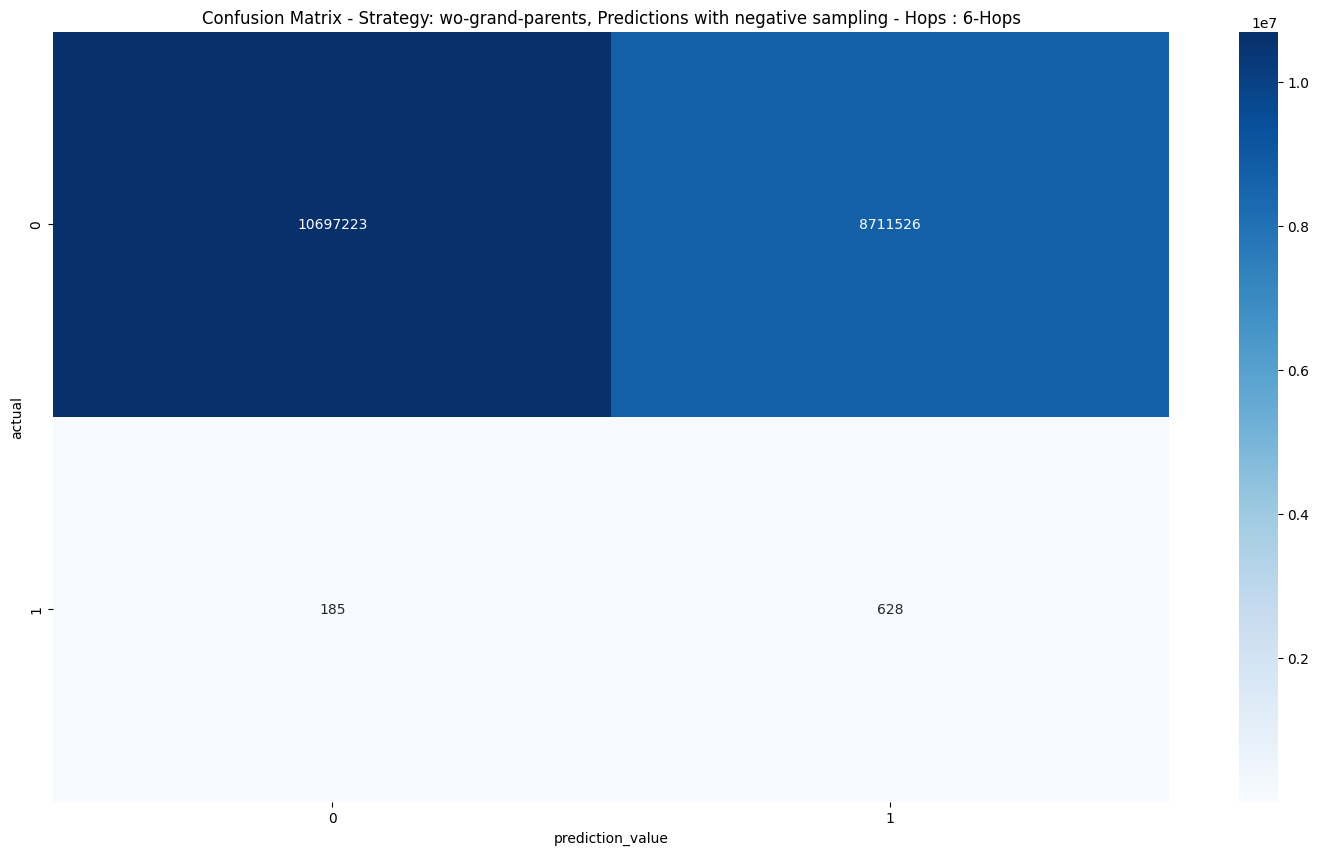

Actual values in top K predictions:  actual
0    16216
1       44
Name: count, dtype: int64


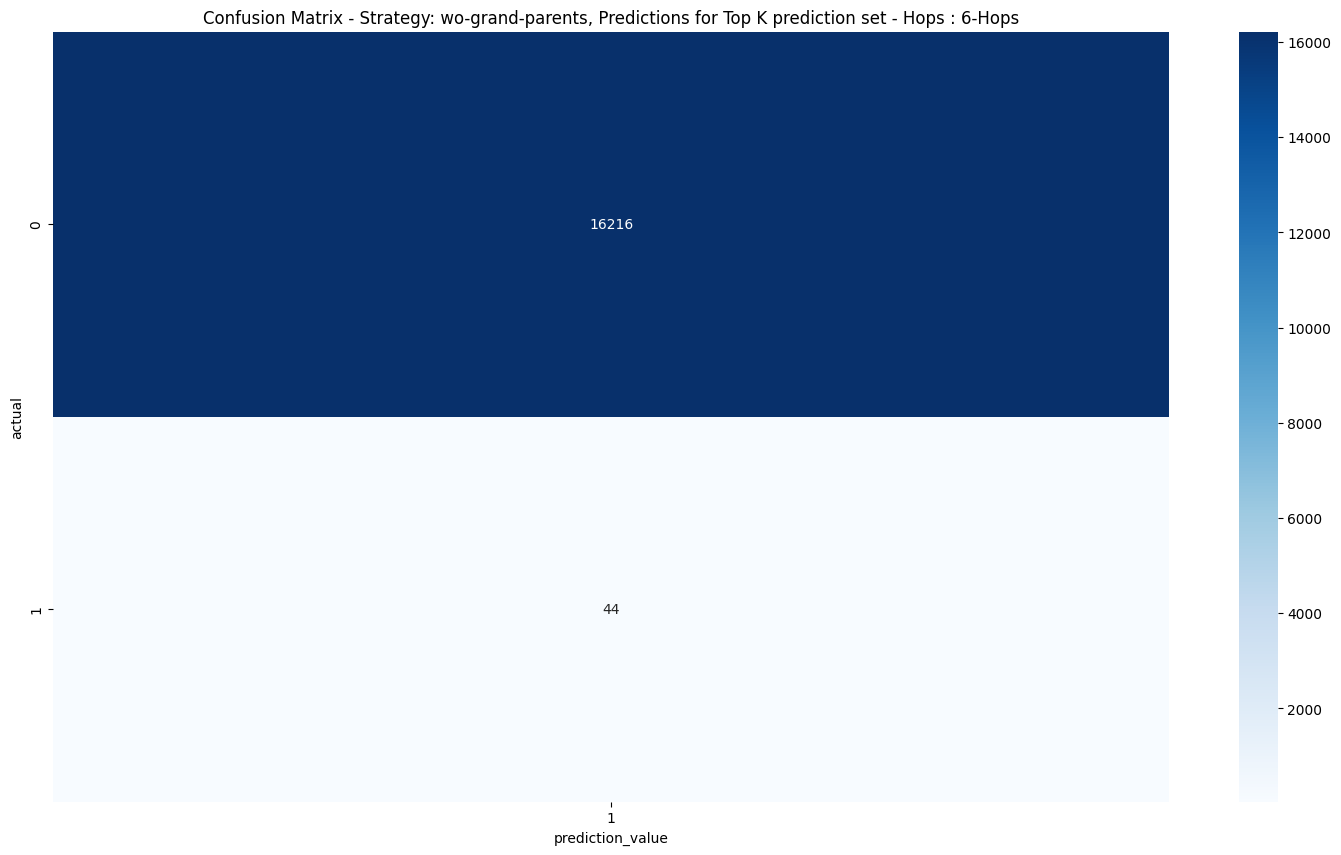

Actual values in test set:  actual
1    5357
Name: count, dtype: int64


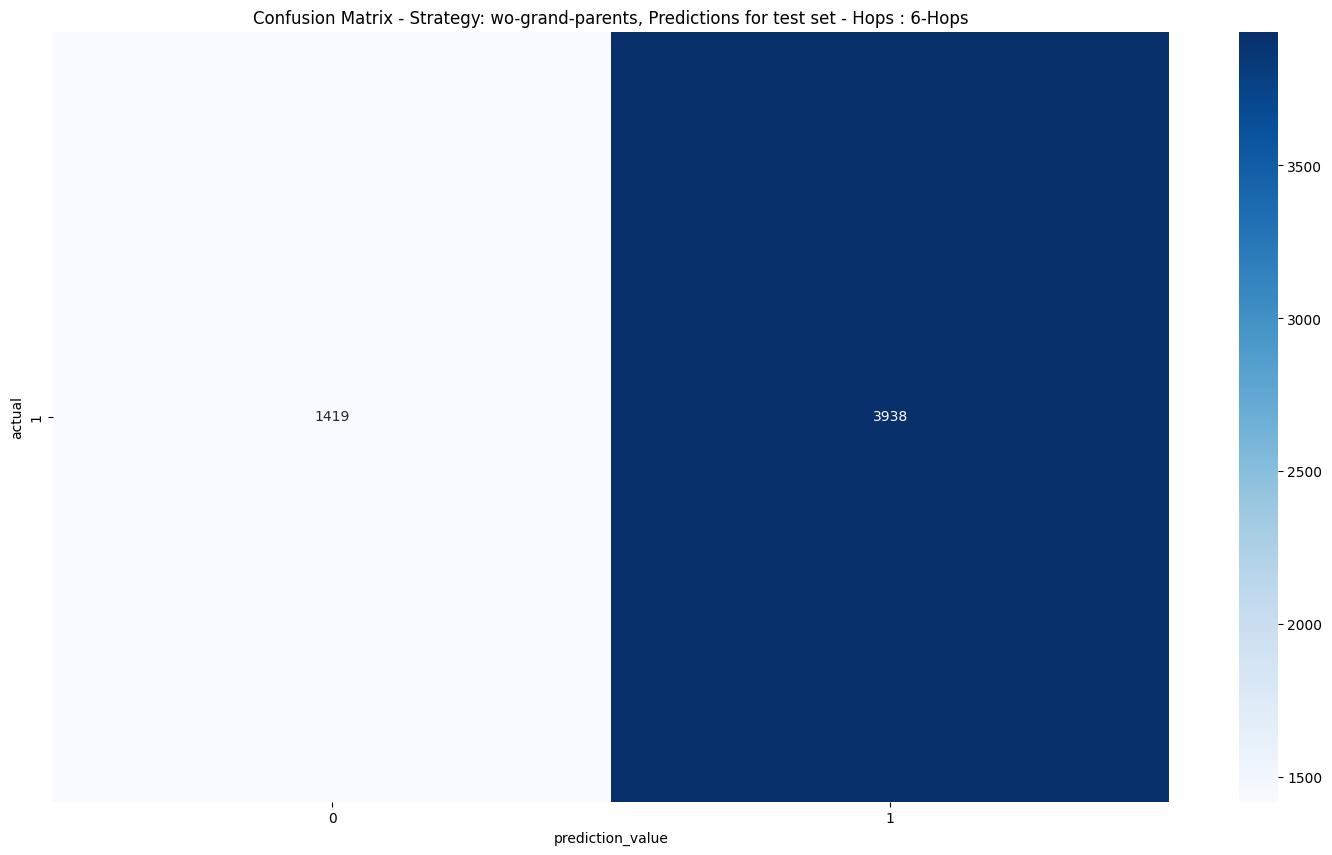

Total observations in test set confusion matrix for wo-grand-parents: 5357


In [31]:
MODEL_TECHNIQUE = "gemma3"
METADATA_PATH = os.path.join(project_root, 'data','preprocessed',DATASET)
TAXONOMY_PATH = os.path.join(project_root, 'data','taxonomy',DATASET)
REDUNDANCY_STRATEGY = "wo-grand-parents"
BATCH_SIZE = "5"
N_HOP = 6

# Load relation data and ensure key columns are strings
gemma_relation = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE}_taxonomy.csv") # contains the relations between items and hierarhcy
gemma_relation['head'] = gemma_relation['head'].astype(str)
gemma_relation['tail'] = gemma_relation['tail'].astype(str)

gemma_taxonomy_batch_size = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE}_taxonomy_batchsize_{5}.csv")
gemma_taxonomy_batch_size_wo_grandparents = KG_Filter().filter_item_to_grandchild_redundancy(gemma_taxonomy_batch_size)

# Load mapping
MAPPING_PATH = os.path.join(project_root, "data","experiments", EXPERIMENT_NAME, DATASET, MODEL_TECHNIQUE,REDUNDANCY_STRATEGY,BATCH_SIZE)
gemma_mapping = pd.read_csv(f"{MAPPING_PATH}/entity_map.csv")

df_metadata = pd.read_csv(f"{METADATA_PATH}/metadata_filtered_df.csv") # contains the metadata for items
df_test = pd.read_csv(f"{METADATA_PATH}/test_df.csv") # contains the test set
df_train = pd.read_csv(f"{METADATA_PATH}/train_df.csv") # contains the train set

print(f"Processing Strategy: {REDUNDANCY_STRATEGY}, Hops: {N_HOP}")
EXPERIMENT_DATA_PATH = os.path.join(project_root,"data","experiments",EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE,REDUNDANCY_STRATEGY,BATCH_SIZE)
error_df = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/{N_HOP}-Hops_predictions.csv")

error_df["user_id"] = error_df["user_id"].map(gemma_mapping.set_index("id")["entity"])
error_df["item_id"] = error_df["item_id"].map(gemma_mapping.set_index("id")["entity"])

process_kg = Process_KG()
error_df = process_kg.process_prediction(error_df)
error_df = process_kg.count_hits(error_df)
error_df['item_id'] = error_df['item_id'].astype(str)
error_df['user_id'] = error_df['user_id'].astype(str)

# Call connect_parents after ensuring types are compatible

error_df = process_kg.connect_parents(error_df, gemma_relation)
error_df = error_df.drop_duplicates(subset=['user_id', 'item_id'], keep='first')
# Check if necessary columns exist before creating confusion matrix
if 'actual' in error_df.columns and 'prediction_value' in error_df.columns:
    confusion_matrix = pd.crosstab(error_df["actual"], error_df["prediction_value"])
    plt.figure() # Create a new figure for each plot
    sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - Strategy: {REDUNDANCY_STRATEGY}, Predictions with negative sampling - Hops : {N_HOP}-Hops")
    plt.show()
else:
    print(f"Skipping confusion matrix for {REDUNDANCY_STRATEGY}: Columns 'actual' or 'prediction_value' not found after processing.")


# top K items
error_df_at_k = error_df.sort_values(by=["user_id","prediction"], ascending=True)
error_df_at_k = error_df_at_k.groupby("user_id").tail(20)
print("Actual values in top K predictions: ",error_df_at_k["actual"].value_counts())
error_df_at_k = process_kg.process_prediction(error_df_at_k)
# error_df_at_k = count_hits(error_df_at_k) # count_hits is not needed here as process_prediction already creates prediction_value

confusion_matrix_at_k = pd.crosstab(error_df_at_k["actual"], error_df_at_k["prediction_value"])
plt.figure() # Create a new figure for each plot
sns.heatmap(confusion_matrix_at_k, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - Strategy: {REDUNDANCY_STRATEGY}, Predictions for Top K prediction set - Hops : {N_HOP}-Hops")
plt.show()

error_df_test = pd.merge(error_df, df_test, left_on=["user_id", "item_id"], right_on=["user_id", "parent_asin"], how="inner")
error_df_test['__temp_is_rating_nan__'] = error_df_test['rating'].isna()

error_df_test = error_df_test.sort_values(
    by=['user_id', 'item_id', '__temp_is_rating_nan__'],
    ascending=[True, True, False] 
)

error_df_test = error_df_test.drop_duplicates(subset=['user_id', 'item_id'], keep='first')
error_df_test["actual"] = 1
# Remove the temporary column.
error_df_test = error_df_test.drop(columns=['__temp_is_rating_nan__'])
confusion_matrix_test = pd.crosstab(error_df_test["actual"], error_df_test["prediction_value"])

print("Actual values in test set: ", error_df_test["actual"].value_counts())

if 'actual' in error_df_test.columns and 'prediction_value' in error_df_test.columns:
    if not error_df_test.empty:
        confusion_matrix_test = pd.crosstab(error_df_test["actual"], error_df_test["prediction_value"])
        plt.figure() # Create a new figure for each plot
        sns.heatmap(confusion_matrix_test, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Confusion Matrix - Strategy: {REDUNDANCY_STRATEGY}, Predictions for test set - Hops : {N_HOP}-Hops")
        plt.show()
        print(f"Total observations in test set confusion matrix for {REDUNDANCY_STRATEGY}: {confusion_matrix_test.sum().sum()}")
    else:
        print(f"Skipping test set confusion matrix for {REDUNDANCY_STRATEGY}: error_df_test is empty after filtering.")
else:
    print(f"Skipping test set confusion matrix for {REDUNDANCY_STRATEGY}: Columns 'actual' or 'prediction_value' not found in error_df_test.")


**Analysis of Prediction Performance Changes**

Top-K Predictions (K=20)
- True positive predictions decreased from 33 to 56 instances
    - Represents a 69.7% decrease in true positives
    - Suggests improved overall precision in identifying relevant items

Test Set Performance
- True positive predictions showed a small improvement
- Test set performance increased from 3931 to 3938 true positives
- Represents a 0.1% improvement in true positive predictions

Negative Sampling Performance
- True negatives showed slight decrease
    - Minor degradtion in identifying irrelevant items
  

Overall Impact
- Top-K performance improvemnt suggests model is better able to ranking true poisitives accordingly 
- Test set and negative sampling stability indicates model didnt got better nor got lot worse in distinguishing relevant and irrelevant items 
- Overall results hence model got fitter understanding user preferences, especialy in bringing them into the top 20 recommendations


Besides the performance we want to observe how the batch size at 5 was able to mitigate other challenges like the potential incomplete taxonomy and the gini coefficient. 

In [6]:
# only keep observation where prediction_sigmoid is higher than 0.5
error_df = error_df[error_df["prediction_sigmoid"] > 0.5]
# group by first level parent and count
error_df_first_level = error_df.groupby("first_level_parent").count()
error_df_item_count = error_df.groupby("item_id").count()

gini_coefficient(error_df_first_level["prediction_value"], "wo-grand-parents batch size 5 for first level parents:")
gini_coefficient(error_df_item_count["prediction_value"], "wo-grand-parents batch size 5 for items:")

Gini score wo-grand-parents batch size 5 for first level parents:: 0.56
Gini score wo-grand-parents batch size 5 for items:: 0.44


0.44354030259141797

## Biases

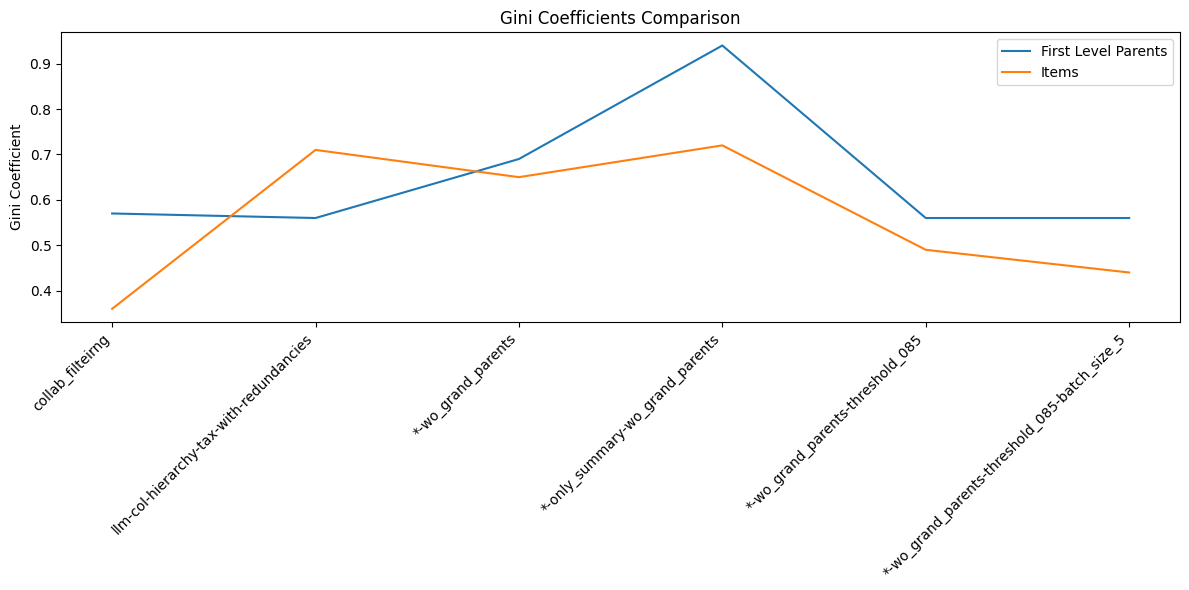

In [7]:
strategies = ["collab_filteirng","llm-col-hierarchy-tax-with-redundancies", "*-wo_grand_parents","*-only_summary-wo_grand_parents","*-wo_grand_parents-threshold_085","*-wo_grand_parents-threshold_085-batch_size_5"]
gini_items = [0.36,0.71,0.65,0.72,0.49,0.44]
gini_first_level = [0.57,0.56,0.69,0.94,0.56, 0.56]

plt.figure(figsize=(12, 6))

# Plot both Gini coefficients on the same graph
plt.plot(strategies, gini_first_level, label='First Level Parents')
plt.plot(strategies, gini_items, label='Items')

plt.title('Gini Coefficients Comparison')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Gini Coefficient')
plt.legend()

plt.tight_layout()
plt.show()




**Analysis of Gini Coefficient Changes with Batch Size 5**

Impact on First Level Parents
 - Gini coefficient decreased to 0.56, matching the lowest value achieved by 3 other models
 - This indicates more balanced distribution of predictions across parent categories
 - Suggests batch size 5 helps reduce category-level bias

Impact on Items
 - Gini coefficient further decreased from 0.49 to 0.44
 - Shows continued improvement in reducing item-level popularity bias
 - Indicates more equitable distribution of predictions across individual items

 Overall Observations
- More conservative knowledge graph approach (threshold + smaller batch size) effectively reduces biases
 - Combination of threshold and batch size 5 shows synergistic effect in bias reduction

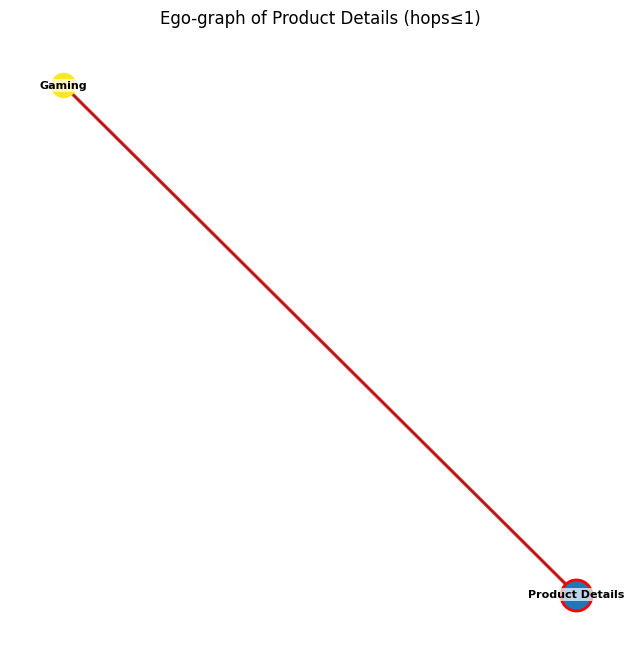

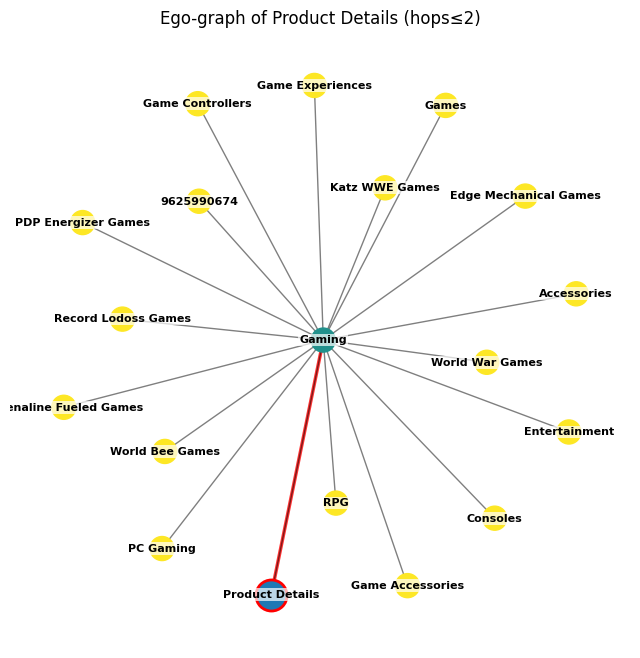

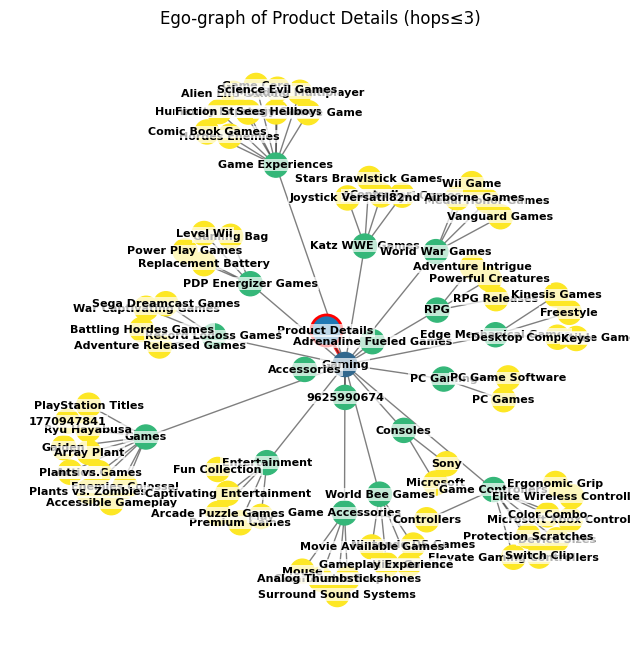

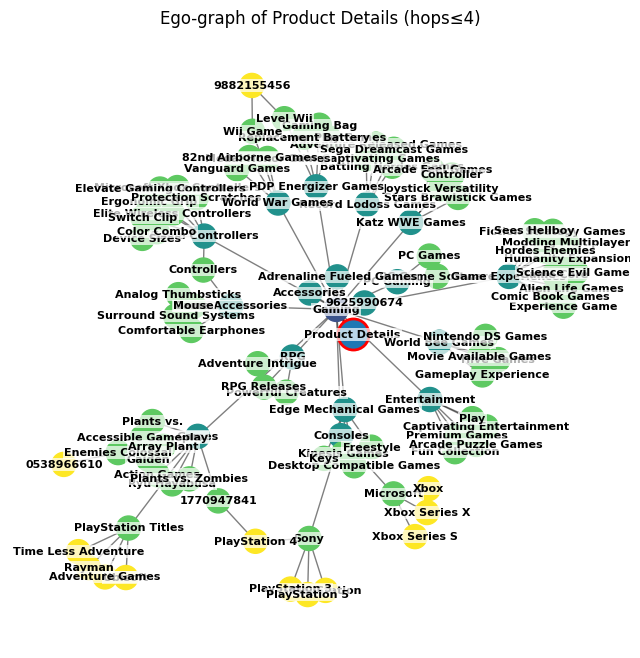

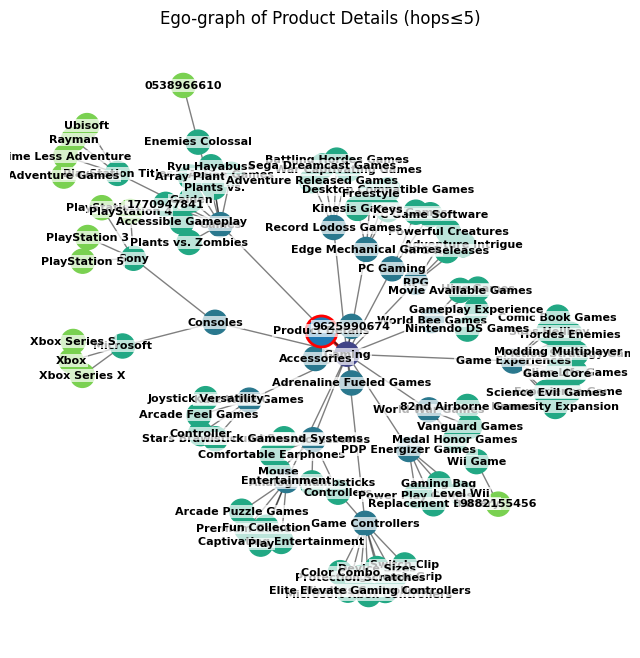

In [8]:
# Filter out product IDs (starting with B0) and category IDs (starting with A)
gemma_taxonomy_batch_size_wo_grandparents_wo_products = gemma_taxonomy_batch_size_wo_grandparents[
    ~gemma_taxonomy_batch_size_wo_grandparents["head"].str.startswith("B0") &
    ~gemma_taxonomy_batch_size_wo_grandparents["head"].str.startswith("A")
]

# Create graph from filtered edgelist
g_taxonomy_batch_size_wo_grandparents_wo_products = nx.from_pandas_edgelist(gemma_taxonomy_batch_size_wo_grandparents_wo_products, source='head', target='tail')

# Visualize the graph
viz = Visualize_KG()
viz.draw_ego_hops(g_taxonomy_batch_size_wo_grandparents_wo_products, center_node="Product Details", hops=1)
viz.draw_ego_hops(g_taxonomy_batch_size_wo_grandparents_wo_products, center_node="Product Details", hops=2)
viz.draw_ego_hops(g_taxonomy_batch_size_wo_grandparents_wo_products, center_node="Product Details", hops=3)
viz.draw_ego_hops(g_taxonomy_batch_size_wo_grandparents_wo_products, center_node="Product Details", hops=4)
viz.draw_ego_hops(g_taxonomy_batch_size_wo_grandparents_wo_products, center_node="Product Details", hops=5)

**Analysis of Batch Size Impact on Taxonomy Structure**

**Taxonomy Coverage**
- MLflow tracing confirms the model maintained task goal and did not drift semantically throughout processing
- No loss of taxonomy structure during batch taxonomy generation, meanwhile batch size 15 wasnt able to prevent taxonomy loss

**Taxonomy Depth**
- Previous batch size (20) produced taxonomy with 3 levels of depth
- Smaller batch size (5) increased depth to 5 levels
- Deeper taxonomy suggests more granular categorization

**Relationship Between Observations**
- Increased depth likely comes from prevention of LLM semantically drift which contributes to taxonomy completeness
- Smaller batches allow for more detailed processing of relationships
- Both coverage and depth improvements appear to be interconnected effects of reduced batch size

In [9]:
# load taxonomy for batch 20 for linking threshold 0.7
gemma_taxonomy_threshold_085_batchsize_20_wo_products = pd.read_csv("/Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/taxonomy/amazon-Video_Games/gemma3_taxonomy_threshold_085_triples.csv")
gemma_taxonomy_threshold_085_batchsize_20_wo_products = gemma_taxonomy_threshold_085_batchsize_20_wo_products[
    ~gemma_taxonomy_threshold_085_batchsize_20_wo_products["head"].str.startswith("B0") &
    ~gemma_taxonomy_threshold_085_batchsize_20_wo_products["head"].str.startswith("A")
]


from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print(f"Cosine similarity of Taxonomy for batch size 20 to batch size 5: {calc_cosine_similarity_fixed(gemma_taxonomy_threshold_085_batchsize_20_wo_products, gemma_taxonomy_batch_size_wo_grandparents_wo_products, embedding_model=embedding_model)}")
print(f"Levenstein similarity of Taxonomy for batch size 20 to batch size 5: {levenshtein_distance(gemma_taxonomy_threshold_085_batchsize_20_wo_products, gemma_taxonomy_batch_size_wo_grandparents_wo_products)}")



Cosine similarity of Taxonomy for batch size 20 to batch size 5: 0.2957863509654999
Levenstein similarity of Taxonomy for batch size 20 to batch size 5: 0.2764975480027804


# Analysis of Taxonomy Similarity Metrics

The low similarity scores between taxonomies generated with different batch sizes (cosine similarity: 0.30, Levenshtein distance: 0.28) reveal important insights about the LLM-COL-Hierarchy process:

1. **Taxonomy coverage**
   - The significant difference suggests that smaller batch sizes enable more comprehensive processing
   - Each keyword receives more focused attention, leading to more specialized categorization
   - The model can better organize relationships when processing fewer items simultaneously

2. **Batch Size Impact**
   - Smaller batch sizes (5) allow the LLM to:
     - Process each keyword more thoroughly
     - Create more covered hierarchical relationships, which can be seen by comparing depths of the taxonomies. (3 to 5)
     - Develop a more nuanced taxonomy structure
   - Larger batch sizes (20) may lead to:
     - More generalized categorization
     - Less detailed relationship mapping
     - Potential loss of specialized connections

3. **Process Optimization**
   - The results suggest that batch size is a critical parameter for taxonomy generation
   - Smaller batches enable better keyword organization and relationship mapping
   - The trade-off between processing speed and taxonomy quality should be carefully considered
    - especially noting the prediction improvements are marginal.

These findings highlight the importance of batch size selection in achieving optimal taxonomy generation results.


### Cherry Picking

To explain the improvements over the last experiments for test set prediction we select cases where false negative item prediction from experiment 1 are in experiment 5 true positive prediction on the test set for a user

In [102]:
experiment_5_predictions = error_df_at_k 

In [72]:
TAXONOMY_PATH = os.path.join(project_root,"data","taxonomy",DATASET)
METADATA_PATH = os.path.join(project_root,"data","preprocessed",DATASET)
EXPERIMENT_DATA_PATH = os.path.join(project_root,"data","experiments","#1 Baseline Implementation",DATASET,"gemma3")
N_HOPS = 6

experiment_1_predictions = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/{N_HOPS}-Hops_predictions.csv") # contains the predictions
experiment_1_mapping_df = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/entity_map.csv") # to convert ids to entity names
experiment_1_taxonomy = pd.read_csv(f"{TAXONOMY_PATH}/gemma3_taxonomy-triples.csv")

experiment_1_predictions["user_id"] = experiment_1_predictions["user_id"].map(experiment_1_mapping_df.set_index("id")["entity"])
experiment_1_predictions["item_id"] = experiment_1_predictions["item_id"].map(experiment_1_mapping_df.set_index("id")["entity"])

experiment_1_predictions = process_kg.process_prediction(experiment_1_predictions)
experiment_1_predictions = process_kg.count_hits(experiment_1_predictions)
experiment_1_predictions["item_id"] = experiment_1_predictions["item_id"].astype(str)
experiment_1_predictions["user_id"] = experiment_1_predictions["user_id"].astype(str)

experiment_1_predictions = process_kg.connect_parents(experiment_1_predictions, experiment_1_taxonomy)
experiment_1_predictions = experiment_1_predictions.sort_values(by=["user_id","prediction"], ascending=True)
experiment_1_predictions = experiment_1_predictions.groupby("user_id").tail(20)
experiment_1_predictions = experiment_1_predictions.drop_duplicates(subset=['user_id', 'item_id'], keep='first')

Accuracy in test set: 0.7055702118107154


In [103]:
print("Experiment 1 all predictions:", len(experiment_1_predictions))
experiment_1_predictions = experiment_1_predictions[experiment_1_predictions["actual"] == 1]
experiment_1_predictions = experiment_1_predictions[experiment_1_predictions["prediction_value"] == 1]
print("Experiment 1 true positive predictions:", len(experiment_1_predictions))


print("Experiment 5 all predictions:", len(experiment_5_predictions))
experiment_5_predictions = experiment_5_predictions[experiment_5_predictions["actual"] == 1]
experiment_5_predictions = experiment_5_predictions[experiment_5_predictions["prediction_value"] == 1]
print("Experiment 5 true positive predictions:", len(experiment_5_predictions))





Experiment 1 all predictions: 4
Experiment 1 true positive predictions: 4
Experiment 5 all predictions: 16260
Experiment 5 true positive predictions: 44


In [104]:
experiment_5_unique_users = experiment_5_predictions["user_id"].unique()
experiment_1_unique_users = experiment_1_predictions["user_id"].unique()

print("Experiment 5 unique users:", len(experiment_5_unique_users))
print("Experiment 1 unique users:", len(experiment_1_unique_users))





Experiment 5 unique users: 44
Experiment 1 unique users: 4


In [105]:
experiment_delta = experiment_5_predictions[experiment_5_predictions["user_id"].isin(experiment_1_predictions["user_id"])]
print("Experiment delta:", len(experiment_delta))

Experiment delta: 2


Interesting to see that from experiment 1 to 5 not a single user with tp are in both dataset. this could be from the noisy graph expeirment 1 which that lead to more randomized tp. to observe this we look at tp predicitons from experiment 4

In [106]:
TAXONOMY_PATH = os.path.join(project_root,"data","taxonomy",DATASET)
METADATA_PATH = os.path.join(project_root,"data","preprocessed",DATASET)
EXPERIMENT_DATA_PATH = os.path.join(project_root,"data","experiments","#4 Linking Hyperparameter treshhold",DATASET,"gemma3","wo-grand-parents","085")
N_HOPS = 6

experiment_4_predictions = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/{N_HOPS}-Hops_predictions.csv") # contains the predictions
experiment_4_mapping_df = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/entity_map.csv") # to convert ids to entity names
experiment_4_taxonomy = pd.read_csv(f"{TAXONOMY_PATH}/gemma3_taxonomy_threshold_085_triples.csv")


experiment_4_predictions["user_id"] = experiment_4_predictions["user_id"].map(experiment_4_mapping_df.set_index("id")["entity"])
experiment_4_predictions["item_id"] = experiment_4_predictions["item_id"].map(experiment_4_mapping_df.set_index("id")["entity"])

experiment_4_predictions = process_kg.process_prediction(experiment_4_predictions)
experiment_4_predictions = process_kg.count_hits(experiment_4_predictions)
experiment_4_predictions["item_id"] = experiment_4_predictions["item_id"].astype(str)
experiment_4_predictions["user_id"] = experiment_4_predictions["user_id"].astype(str)

experiment_4_predictions = process_kg.connect_parents(experiment_4_predictions, experiment_4_taxonomy)
experiment_4_predictions = experiment_4_predictions.sort_values(by=["user_id","prediction"], ascending=True)
experiment_4_predictions = experiment_4_predictions.groupby("user_id").tail(20)
experiment_4_predictions = experiment_4_predictions.drop_duplicates(subset=['user_id', 'item_id'], keep='first')
experiment_4_predictions = experiment_4_predictions[experiment_4_predictions["actual"] == 1]
experiment_4_predictions = experiment_4_predictions[experiment_4_predictions["prediction_value"] == 1]
print("Experiment 4 true positive predictions:", len(experiment_4_predictions))

Accuracy in test set: 0.5690049270071582
Experiment 4 true positive predictions: 28


In [117]:
print("unique users in experiment 4:", len(experiment_4_predictions["user_id"].unique()))
print("unique users in experiment 5:", len(experiment_5_predictions["user_id"].unique()))

experiment_intersection = experiment_5_predictions[experiment_5_predictions["user_id"].isin(experiment_4_predictions["user_id"])]
print("Experiment intersection:", len(experiment_intersection))
print("unique users in experiment intersection:", len(experiment_intersection["user_id"].unique()))

# distinct users in 5 compared to 4 
experiment_5_distinction = experiment_5_predictions[~experiment_5_predictions["user_id"].isin(experiment_4_predictions["user_id"])]
print("Experiment 5 distinction:", len(experiment_5_distinction))
print("unique users in experiment 5 distinction:", len(experiment_5_distinction["user_id"].unique()))


unique users in experiment 4: 28
unique users in experiment 5: 44
Experiment intersection: 8
unique users in experiment intersection: 8
Experiment 5 distinction: 36
unique users in experiment 5 distinction: 36


as we can see in all experiments all users have only 1 tp in test set

In [108]:
experiment_5_with_intersection = experiment_5_predictions[experiment_5_predictions["user_id"].isin(experiment_intersection["user_id"])]
print("Experiment 5 with intersection:", len(experiment_5_with_intersection))

experiment_4_with_intersection = experiment_4_predictions[experiment_4_predictions["user_id"].isin(experiment_intersection["user_id"])]
print("Experiment 4 with intersection:", len(experiment_4_with_intersection))

Experiment 5 with intersection: 8
Experiment 4 with intersection: 8


From the 44 tp for 44 users from experiment 5 and 28 tp for 28 user in experiment 4 we observe in intersection of 8 user. 
Due to the lack of multiple tp for users its not possible to observe if the less noisy structure was able to understand for indivdual user better preferences which boost predicitons for them


In [111]:
# Count items consumed per user in test set for both experiments
print("=== Items consumed per user in test set ===")

# For experiment 4
print("\nExperiment 4 - Items consumed per user:")
exp4_user_consumption = experiment_4_predictions.groupby('user_id').size().reset_index(name='items_consumed')
print(exp4_user_consumption)

# For experiment 5  
print("\nExperiment 5 - Items consumed per user:")
exp5_user_consumption = experiment_5_predictions.groupby('user_id').size().reset_index(name='items_consumed')
print(exp5_user_consumption)

# Summary statistics
print(f"\nExperiment 4 - Average items per user: {exp4_user_consumption['items_consumed'].mean():.2f}")
print(f"Experiment 5 - Average items per user: {exp5_user_consumption['items_consumed'].mean():.2f}")

# Check if all users have only 1 item consumed (as suggested in markdown)
print(f"\nExperiment 4 - Users with exactly 1 item: {len(exp4_user_consumption[exp4_user_consumption['items_consumed'] == 1])}")
print(f"Experiment 5 - Users with exactly 1 item: {len(exp5_user_consumption[exp5_user_consumption['items_consumed'] == 1])}")

=== Items consumed per user in test set ===

Experiment 4 - Items consumed per user:
                         user_id  items_consumed
0   AE2AZ2MNROPF33U6SS53VI22OXJA               1
1   AE6TYE5PT4ERDWQ52NQM75LBIVOA               1
2   AEDCDJHLA36IJLFX7QCZTDHQDCKA               1
3   AEHADYIAEXCRW7PICMN4VQFMDCOA               1
4   AEKMOOO4KWY3MG4M2CXWFQQ7Q5CA               1
5   AEL2R4MC45LYX2PYNENOZGY6VAKA               1
6   AENOG3KAJXJXJUSRAGBJM67TZE4A               1
7   AETEEKM7PARPRYDBP4JIH6LIRHJA               1
8   AF6SM2ESLD534XWS7P6PFSL257CA               1
9   AF7HLITNFXJTHYDBCETCJOGOVGIQ               1
10  AFAMGPOV26EZJNSDGHKLF3YYW2UQ               1
11  AFFCUWONA4J7TAVQUTKN43V6SNCA               1
12  AFNMLCKSUI5YJO5GWRATK6VQL3OA               1
13  AFPGIZLXD2OW642JHCLMJRLGTBZQ               1
14  AFRY27GPRRTESTN746JGSGNPGW5Q               1
15  AFVOE542SS4USJUIKZY4RWPAFTMA               1
16  AFVV7CLXY43P3Z3F7SROBZATZVSQ               1
17  AG4JCKWTJS3ZDLOIVIBHL6YMKT5Q 

It is observed that for all users with true positives (TP) in both experiment 4 and experiment 5, it is not possible to have multiple true positives because all users only consumed 1 item in the test dataset. This sparsity constraint limits the observability of whether the less noisy knowledge graph structure helps better understand individual user preferences, as we cannot assess if the improved taxonomic structure leads to enhanced prediction accuracy for users with multiple consumption patterns.

In [112]:
experiment_5_predictions = experiment_5_predictions.merge(df_metadata, left_on=["item_id"], right_on=["parent_asin"], how="inner")
experiment_4_predictions = experiment_4_predictions.merge(df_metadata, left_on=["item_id"], right_on=["parent_asin"], how="inner")


In [114]:
experiment_4_predictions

,user_id,item_id,prediction,actual,prediction_sigmoid,prediction_value,prediction_correct,prediction_positive,prediction_negative,first_level_parent,...,videos_y,store_y,categories_y,details_y,parent_asin_y,bought_together_y,subtitle_y,author_y,source_text_y,generated_description_y
0,AE2AZ2MNROPF33U6SS53VI22OXJA,B0BTLHNPDT,28.406036,1,1.0,1,True,True,False,NaN,...,{'title': ['Disc Edition Face Plates with Cool...,VLANMON,"'Video Games', 'PlayStation 5', 'Accessories',...","Product Dimensions: 15.5 x 10.3 x 0.2 inches, ...",B0BTLHNPDT,NaN,NaN,NaN,Parent ASIN: B0BTLHNPDT; Title: Disc Edition F...,'Disc Edition Face Plates with Cooling Vents C...
1,AE6TYE5PT4ERDWQ52NQM75LBIVOA,B08LND59KQ,24.572340,1,1.0,1,True,True,False,NaN,...,"{'title': [], 'url': [], 'user_id': []}",1Mii,"'Video Games', 'Nintendo Switch', 'Accessories...","Package Dimensions: 3.11 x 3.11 x 1.26 inches,...",B08LND59KQ,NaN,NaN,NaN,Parent ASIN: B08LND59KQ; Title: 1Mii Bluetooth...,1mii's speaker is compatible with a computer ....
2,AEDCDJHLA36IJLFX7QCZTDHQDCKA,B07W6P6JJ6,31.079258,1,1.0,1,True,True,False,NaN,...,"{'title': ['Product was a hit or miss...', 'Su...",Assenic,"'Video Games', 'Legacy Systems', 'Nintendo Sys...","Brand: Assenic, Hardware Platform: Nintendo Sw...",B07W6P6JJ6,NaN,NaN,NaN,Parent ASIN: B07W6P6JJ6; Title: Assenic Joysti...,NS Joy-Con & Switch Lite Controller Analog Thu...
3,AEHADYIAEXCRW7PICMN4VQFMDCOA,B0CDK8Q5T7,28.305208,1,1.0,1,True,True,False,NaN,...,"{'title': ['The look and fill omg!', 'Review o...",AreMe,"'Video Games', 'Xbox One', 'Accessories', 'Bat...","Product Dimensions: 2.24 x 2.05 x 1.18 inches,...",B0CDK8Q5T7,NaN,NaN,NaN,Parent ASIN: B0CDK8Q5T7; Title: AreMe Charging...,areMe Charging Station Dock for Xbox Elite Wir...
4,AEKMOOO4KWY3MG4M2CXWFQQ7Q5CA,B0B76QHLQD,24.937490,1,1.0,1,True,True,False,NaN,...,"{'title': ['Good quality, very comfortable, ea...",BINBOK VR,"'Video Games', 'PC', 'Virtual Reality', 'Heads...",Package Dimensions: 10.43 x 7.17 x 2.28 inches...,B0B76QHLQD,NaN,NaN,NaN,Parent ASIN: B0B76QHLQD; Title: BINBOK VR Head...,BINBOK VR Head Strap with Battery Pack for Ocu...
5,AEL2R4MC45LYX2PYNENOZGY6VAKA,B07KXFB1P8,26.585163,1,1.0,1,True,True,False,Xbox,...,"{'title': [], 'url': [], 'user_id': []}",Nyko,"'Video Games', 'Xbox One', 'Accessories', 'Acc...","Release date: April 30, 2021, Best Sellers Ran...",B07KXFB1P8,NaN,NaN,NaN,Parent ASIN: B07KXFB1P8; Title: Nyko Xbox Powe...,Nyko Power Kit Plus for Xbox One and Xbox X|S ...
6,AENOG3KAJXJXJUSRAGBJM67TZE4A,B08T1F8P4T,32.243698,1,1.0,1,True,True,False,NaN,...,"{'title': ['Amazing', 'What a nice keyboard', ...",Keychron,"'Video Games', 'PC', 'Accessories', 'Gaming Ke...","Product Dimensions: 5.08 x 14.8 x 1.5 inches, ...",B08T1F8P4T,NaN,NaN,NaN,Parent ASIN: B08T1F8P4T; Title: Keychron K4 Wi...,Keychron K4 Wireless Bluetooth/USB Wired Gamin...
7,AETEEKM7PARPRYDBP4JIH6LIRHJA,B09Y8F819V,26.198814,1,1.0,1,True,True,False,NaN,...,"{'title': ['Awesome', 'A well-made controller ...",BEITONG,NaN,Pricing: The strikethrough price is the List P...,B09Y8F819V,NaN,NaN,NaN,Parent ASIN: B09Y8F819V; Title: BEITONG i1 MFi...,beitONG i1 mFi Game Controller for iPad iPhone...
8,AF6SM2ESLD534XWS7P6PFSL257CA,B09LHB9HX9,32.093460,1,1.0,1,True,True,False,NaN,...,{'title': ['Sonicon Preloaded Retropie Emulati...,Sonicon,"'Video Games', 'Legacy Systems', 'PlayStation ...","Package Dimensions: 5 x 2.76 x 1.3 inches, Ite...",B09LHB9HX9,NaN,NaN,NaN,Parent ASIN: B09LHB9HX9; Title: Sonicon Preloa...,"manufacturer: Sonicon, country of origin: Chin..."
9,AF7HLITNFXJTHYDBCETCJOGOVGIQ,B08CBHRYM7,22.426319,1,1.0,1,True,True,False,NaN,...,"{'title': ['Skully Launch Trailer', 'Nintendo ...",Maximum Games,"'Video Games', 'Nintendo Switch', 'Games'","Release date: August 4, 2020, Best Sellers Ran...",B08CBHRYM7,NaN,NaN,NaN,Parent ASIN: B08CBHRYM7; Title: Skully (NSW) -...,enigmatic deity reanimates skull on shore of s...


In [120]:
selected_users = experiment_intersection["user_id"].tolist()

analysis_df = pd.DataFrame()

for user_id in selected_users:
    # all train items for user with merged metadata
    user_train = df_train[df_train["user_id"] == user_id]
    user_train = user_train.merge(df_metadata, left_on=["parent_asin"], right_on=["parent_asin"], how="inner")
    # all test items for user with merged metadata
    user_test = df_test[df_test["user_id"] == user_id]
    user_test = user_test.merge(df_metadata, left_on=["parent_asin"], right_on=["parent_asin"], how="inner")
    
    user_exp4_pred = experiment_4_predictions[experiment_4_predictions["user_id"] == user_id]
    user_exp5_pred = experiment_5_predictions[experiment_5_predictions["user_id"] == user_id]
    
    user_df = {
        'user_id': user_id,
        'train_items_consumed': user_train['parent_asin'].tolist(),
        'train_items_source_text': user_train['source_text'].tolist(),
        'train_items_count': len(user_train),
        'test_items_consumed': user_test['parent_asin'].tolist(),
        'test_items_source_text': user_test['source_text'].tolist(),
        'test_items_count': len(user_test),
        'exp4_predicted_items': user_exp4_pred['item_id'].tolist() if len(user_exp4_pred) > 0 else [],
        'exp4_predicted_count': len(user_exp4_pred),
        'exp5_predicted_items': user_exp5_pred['item_id'].tolist() if len(user_exp5_pred) > 0 else [],
        'exp5_predicted_count': len(user_exp5_pred),
        'exp4_predicted_source_text': user_exp4_pred['source_text_x'].tolist() if len(user_exp4_pred) > 0 else [],
        'exp5_predicted_source_text': user_exp5_pred['source_text_x'].tolist() if len(user_exp5_pred) > 0 else []
    }
    analysis_df = pd.concat([analysis_df, pd.DataFrame([user_df])], ignore_index=True)


# loop over user in analysis_df and print the train and test items consumed
for index, row in analysis_df.iterrows():
    print(f"User {row['user_id']}:")
    
    # Loop over train items and display source text
    print("  Train items:")
    for i, item in enumerate(row['train_items_consumed']):
        print(f"    Item {i+1}: {item}")
        print(f"    Source text: {row['train_items_source_text'][i]}")
    
    # Loop over test items and display source text
    print("  Test items:")
    for i, item in enumerate(row['test_items_consumed']):
        print(f"    Item {i+1}: {item}")
        print(f"    Source text: {row['test_items_source_text'][i]}")
    
    # Loop over experiment 4 predicted items and display source text
    print("  Experiment 4 predicted items:")
    for i, item in enumerate(row['exp4_predicted_items']):
        print(f"    Item {i+1}: {item}")
        print(f"    Source text: {row['exp4_predicted_source_text'][i]}")
    # Loop over experiment 5 predicted items and display source text
    print("  Experiment 5 predicted items:")
    for i, item in enumerate(row['exp5_predicted_items']):
        print(f"    Item {i+1}: {item}")
        print(f"    Source text: {row['exp5_predicted_source_text'][i]}")
    print("--------------------------------")  # Empty line for better readability




User AE6TYE5PT4ERDWQ52NQM75LBIVOA:
  Train items:
    Item 1: B0009VXAM0
    Source text: Parent ASIN: B0009VXAM0; Title: PlayStation 3 60GB SystemDescription: Description: 'Product Description', Sony PlayStation 3 60GB (NEW, Unopened, Sealed) Experience the next generation of gaming with the Sony PlayStation 3. It boasts impressive high-definition graphics and multichannel sound that engage you in the on-screen action. And this home entertainment powerhouse goes beyond gaming, offering a wealth of multimedia and networking features. Cutting-edge, high-def graphics and wraparound sound The PlayStation 3's remarkable performance starts with the Cell ; an efficient, state-of-the-art processor designed from the ground up with next-gen gaming in mind. The Cell and the PS3's powerful graphics engine work together to pump out high-definition images with realistic textures and elaborate detail. This console can even output games in 1080p to perfectly complement today's top-of-the-line HDTVs. 

AF7HLITNFXJTHYDBCETCJOGOVGIQ train mainly wii and wii u related items, was able to detect test item nintendo switch


AG4JCKWTJS3ZDLOIVIBHL6YMKT5Q more diverse with console focus xbox games xbox, playstation vita, playstation 4 and was able to predict travel case in test

In [119]:
selected_users = experiment_5_distinction["user_id"].tolist()

analysis_df = pd.DataFrame()

for user_id in selected_users:
    # all train items for user with merged metadata
    user_train = df_train[df_train["user_id"] == user_id]
    user_train = user_train.merge(df_metadata, left_on=["parent_asin"], right_on=["parent_asin"], how="inner")
    # all test items for user with merged metadata
    user_test = df_test[df_test["user_id"] == user_id]
    user_test = user_test.merge(df_metadata, left_on=["parent_asin"], right_on=["parent_asin"], how="inner")
    
    user_exp4_pred = experiment_4_predictions[experiment_4_predictions["user_id"] == user_id]
    user_exp5_pred = experiment_5_predictions[experiment_5_predictions["user_id"] == user_id]
    
    user_df = {
        'user_id': user_id,
        'train_items_consumed': user_train['parent_asin'].tolist(),
        'train_items_source_text': user_train['source_text'].tolist(),
        'train_items_count': len(user_train),
        'test_items_consumed': user_test['parent_asin'].tolist(),
        'test_items_source_text': user_test['source_text'].tolist(),
        'test_items_count': len(user_test),
        'exp4_predicted_items': user_exp4_pred['item_id'].tolist() if len(user_exp4_pred) > 0 else [],
        'exp4_predicted_count': len(user_exp4_pred),
        'exp5_predicted_items': user_exp5_pred['item_id'].tolist() if len(user_exp5_pred) > 0 else [],
        'exp5_predicted_count': len(user_exp5_pred),
        'exp4_predicted_source_text': user_exp4_pred['source_text_x'].tolist() if len(user_exp4_pred) > 0 else [],
        'exp5_predicted_source_text': user_exp5_pred['source_text_x'].tolist() if len(user_exp5_pred) > 0 else []
    }
    analysis_df = pd.concat([analysis_df, pd.DataFrame([user_df])], ignore_index=True)


# loop over user in analysis_df and print the train and test items consumed
for index, row in analysis_df.iterrows():
    print(f"User {row['user_id']}:")
    
    # Loop over train items and display source text
    print("  Train items:")
    for i, item in enumerate(row['train_items_consumed']):
        print(f"    Item {i+1}: {item}")
        print(f"    Source text: {row['train_items_source_text'][i]}")
    
    # Loop over test items and display source text
    print("  Test items:")
    for i, item in enumerate(row['test_items_consumed']):
        print(f"    Item {i+1}: {item}")
        print(f"    Source text: {row['test_items_source_text'][i]}")
    
    # Loop over experiment 4 predicted items and display source text
    print("  Experiment 4 predicted items:")
    for i, item in enumerate(row['exp4_predicted_items']):
        print(f"    Item {i+1}: {item}")
        print(f"    Source text: {row['exp4_predicted_source_text'][i]}")
    # Loop over experiment 5 predicted items and display source text
    print("  Experiment 5 predicted items:")
    for i, item in enumerate(row['exp5_predicted_items']):
        print(f"    Item {i+1}: {item}")
        print(f"    Source text: {row['exp5_predicted_source_text'][i]}")
    print("--------------------------------")  # Empty line for better readability


User AE4IFQLINUBOZBP7RMCTICSULMGQ:
  Train items:
    Item 1: B0007KWOR0
    Source text: Parent ASIN: B0007KWOR0; Title: U.N. SquadronDescription: Description: 'Cartridge only with some minor wear.';- Details: Pricing: The strikethrough price is the List Price. Savings represents a discount off the List Price., Product Dimensions: 8 x 4 x 10 inches; 4.96 Ounces, Type of item: Video Game, Is Discontinued By Manufacturer: No, Item Weight: 5 ounces, Manufacturer: Capcom, Date First Available: January 17, 2005; Store: Store: Capcom;
    Item 2: B0044DE88E
    Source text: Parent ASIN: B0044DE88E; Title: Centipede: Infestation - Nintendo 3DSDescription: Description: 'Product Description', 'Play as Max, the hero and bug slayer, who must defend Maisy, a girl whose gardens bring life back to the wasteland. Squash giant mutated centipedes, spiders, beetles, grubs, caterpillars, moths, and more. Lay waste to these mutated bugs with weapons such as machine guns, flame throwers, acid guns, rocket

In [121]:
experiment_5_taxonomy = pd.read_csv(f"{TAXONOMY_PATH}/gemma3_taxonomy_batchsize_5.csv")
experiment_4_taxonomy = pd.read_csv(f"{TAXONOMY_PATH}/gemma3_taxonomy_threshold_085_triples.csv")




No self-loops found in the taxonomy.
No item-to-grandchild redundant relationships (item -> child -> grandchild pattern) found.
Original relations DataFrame size: 108
Filtered relations DataFrame size: 108


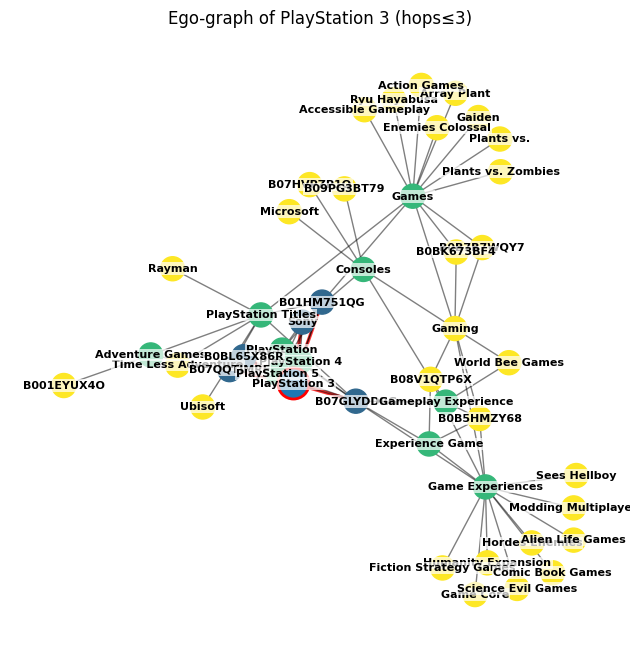

In [151]:
experiment_5_taxonomy_isolated = experiment_5_taxonomy.iloc[0:108].reset_index(drop=True)
experiment_5_taxonomy_isolated = KG_Filter().filter_item_to_grandchild_redundancy(experiment_5_taxonomy_isolated)

experiment_5_predictions_items = experiment_5_predictions["item_id"].tolist()
experiment_5_item_connections = experiment_5_taxonomy[experiment_5_taxonomy["head"].isin(experiment_5_predictions_items)].reset_index(drop=True)
experiment_5_item_connections.head(10)

# concatenate with isolated taxonomy
experiment_5_taxonomy_isolated_with_items = pd.concat([experiment_5_taxonomy_isolated, experiment_5_item_connections], ignore_index=True)
g_experiment_5_taxonomy_isolated_with_items = nx.from_pandas_edgelist(experiment_5_taxonomy_isolated_with_items, source='head', target='tail')



#draw ego hops 
viz.draw_ego_hops(g_experiment_5_taxonomy_isolated_with_items, "PlayStation 3", 3)


Found 2 self-loops in the taxonomy.
No item-to-grandchild redundant relationships (item -> child -> grandchild pattern) found.
Original relations DataFrame size: 34
Filtered relations DataFrame size: 34
Experiment 4 Taxonomy without items


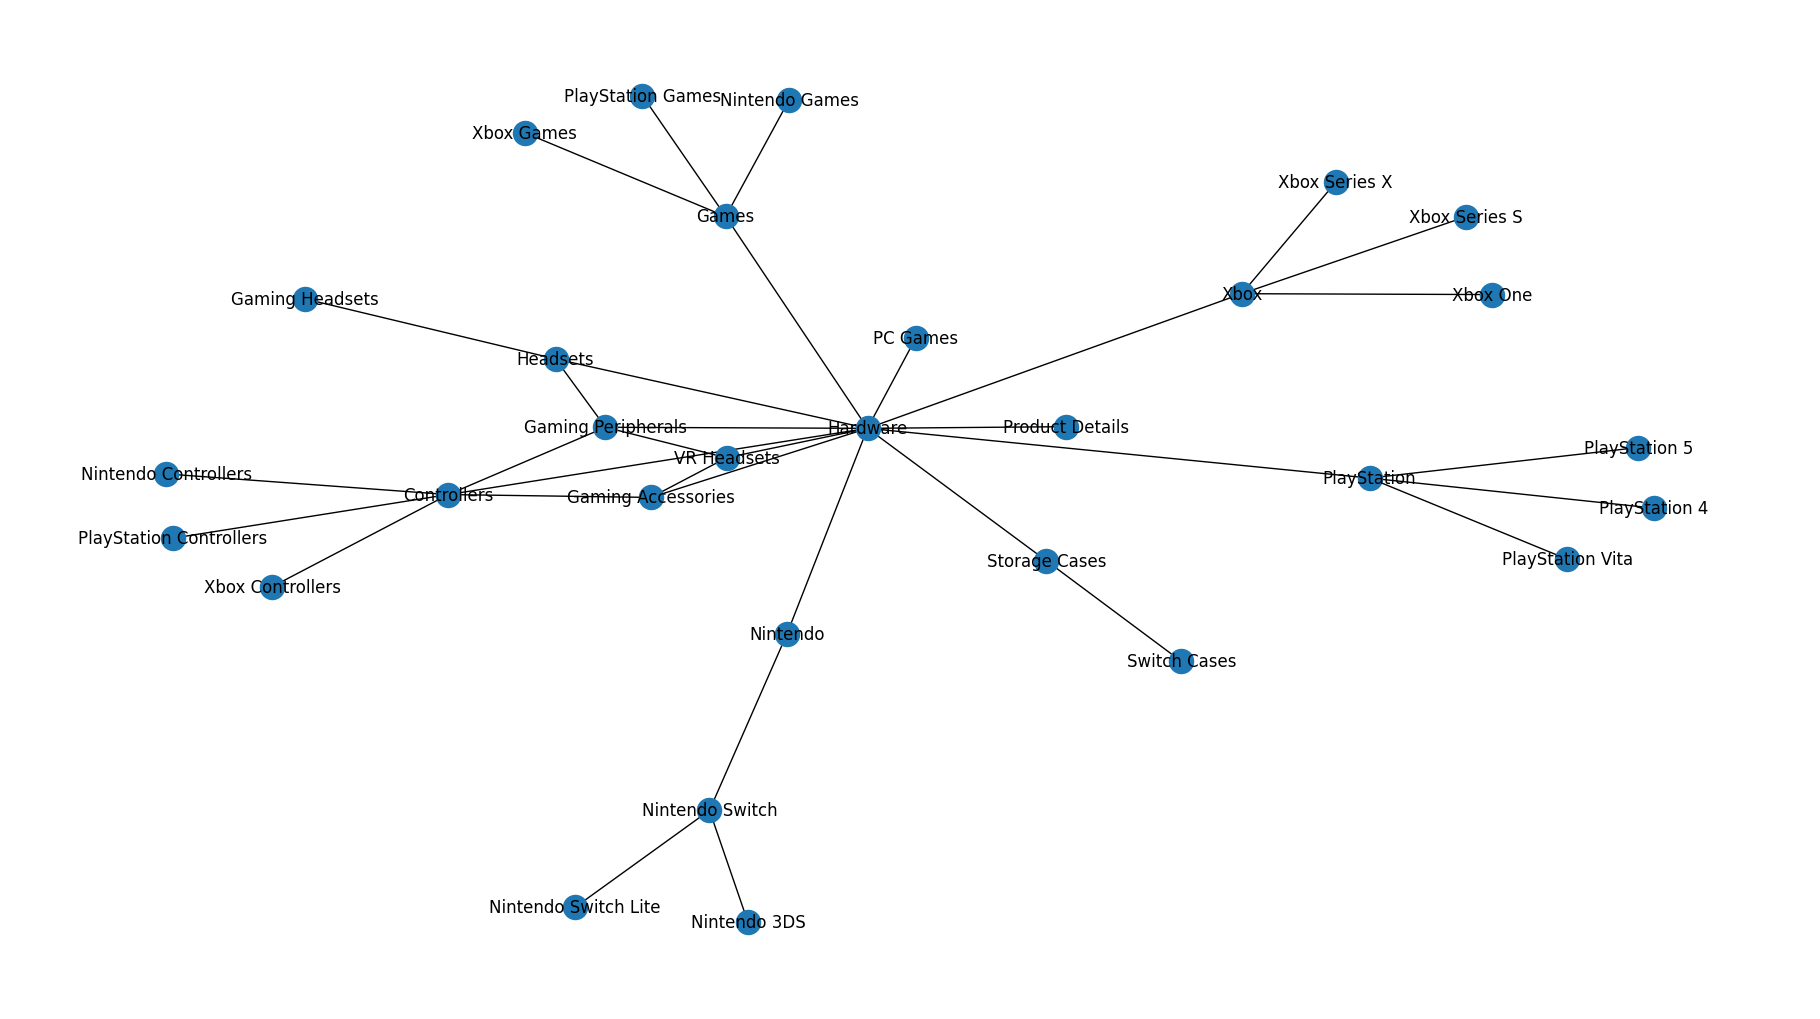

Experiment 4 Taxonomy with selected items (tp from experiment 4)


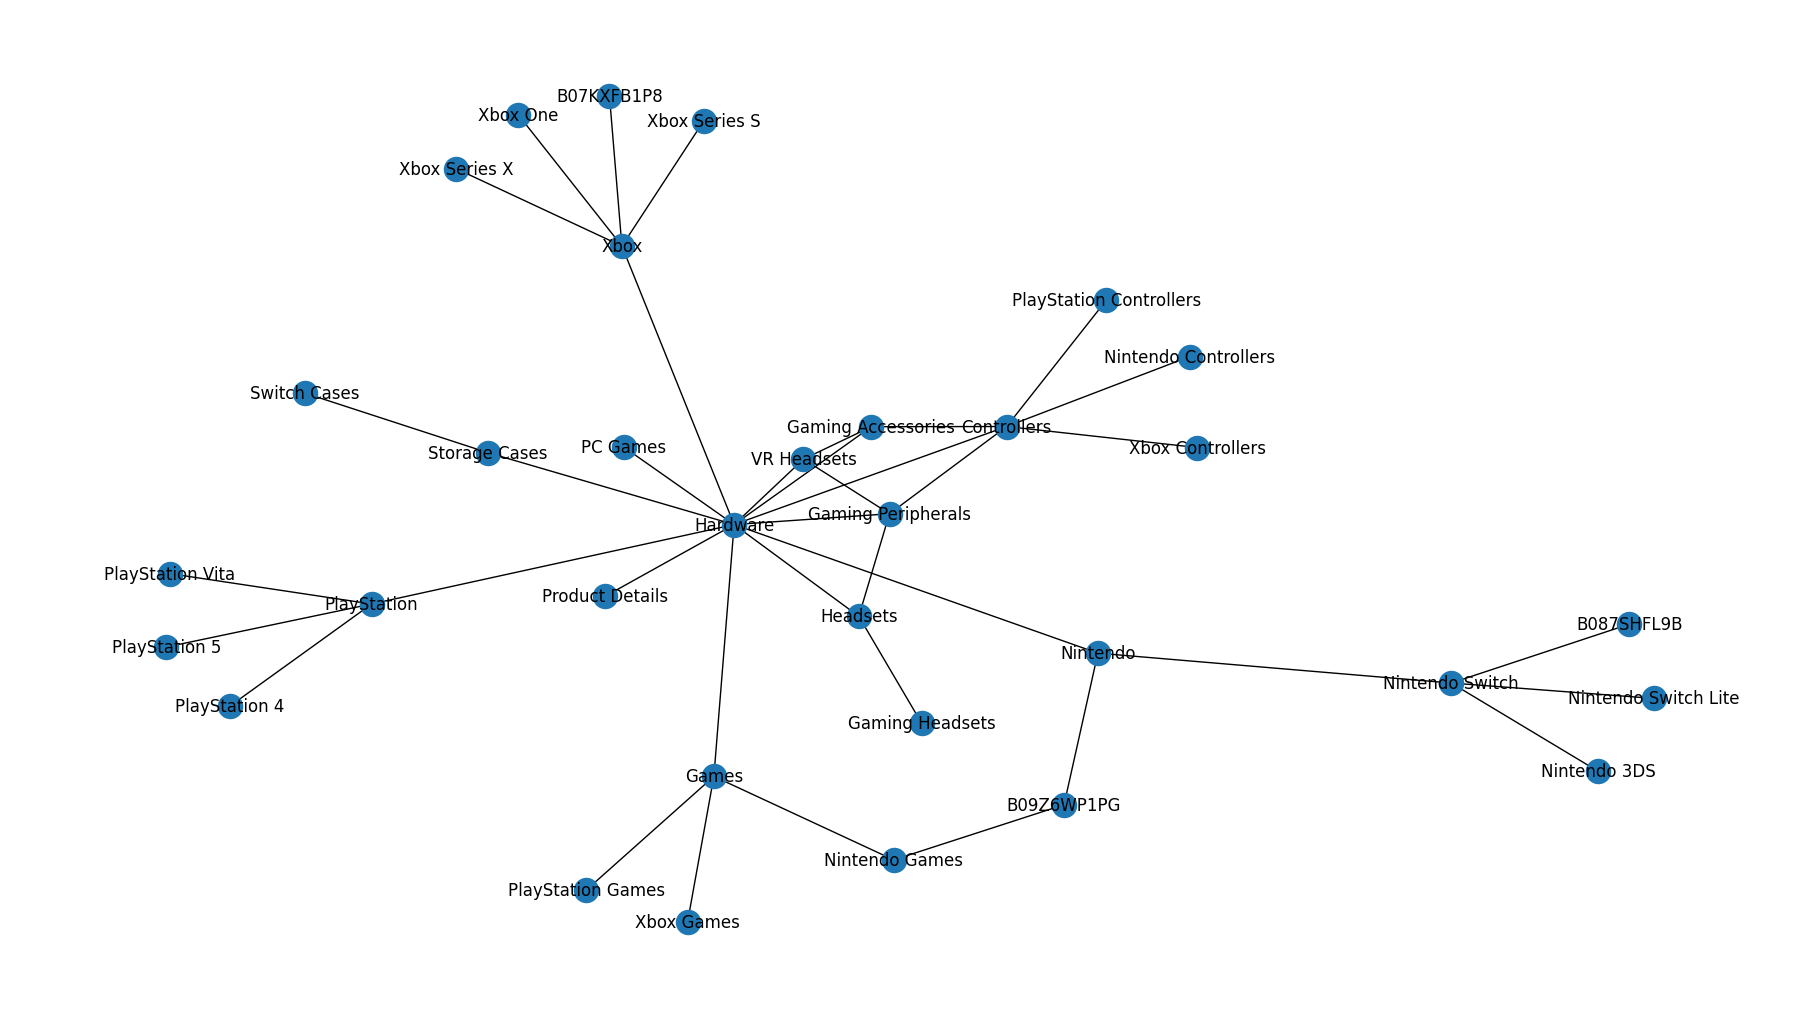

In [156]:
experiment_4_taxonomy_isolated = experiment_4_taxonomy.iloc[0:36].reset_index(drop=True)
experiment_4_taxonomy_isolated = KG_Filter().filter_item_to_grandchild_redundancy(experiment_4_taxonomy_isolated)

experiment_4_predictions_items = experiment_4_predictions["item_id"].tolist()
experiment_4_item_connections = experiment_4_taxonomy[experiment_4_taxonomy["head"].isin(experiment_4_predictions_items)].reset_index(drop=True)
experiment_4_item_connections.head(10)
# concatenate with isolated taxonomy
experiment_4_taxonomy_isolated_with_items = pd.concat([experiment_4_taxonomy_isolated, experiment_4_item_connections], ignore_index=True)
g_experiment_4_taxonomy_isolated_with_items = nx.from_pandas_edgelist(experiment_4_taxonomy_isolated_with_items, source='head', target='tail')



print("Experiment 4 Taxonomy without items")
g_experiment_4_taxonomy_isolated = nx.from_pandas_edgelist(experiment_4_taxonomy_isolated, source='head', target='tail')
nx.draw(g_experiment_4_taxonomy_isolated, with_labels=True)
plt.show()

print("Experiment 4 Taxonomy with selected items (tp from experiment 4)")
g_experiment_4_taxonomy_isolated_with_items = nx.from_pandas_edgelist(experiment_4_taxonomy_isolated_with_items, source='head', target='tail')
nx.draw(g_experiment_4_taxonomy_isolated_with_items, with_labels=True)
plt.show()




Experiment 5 Taxonomy without items


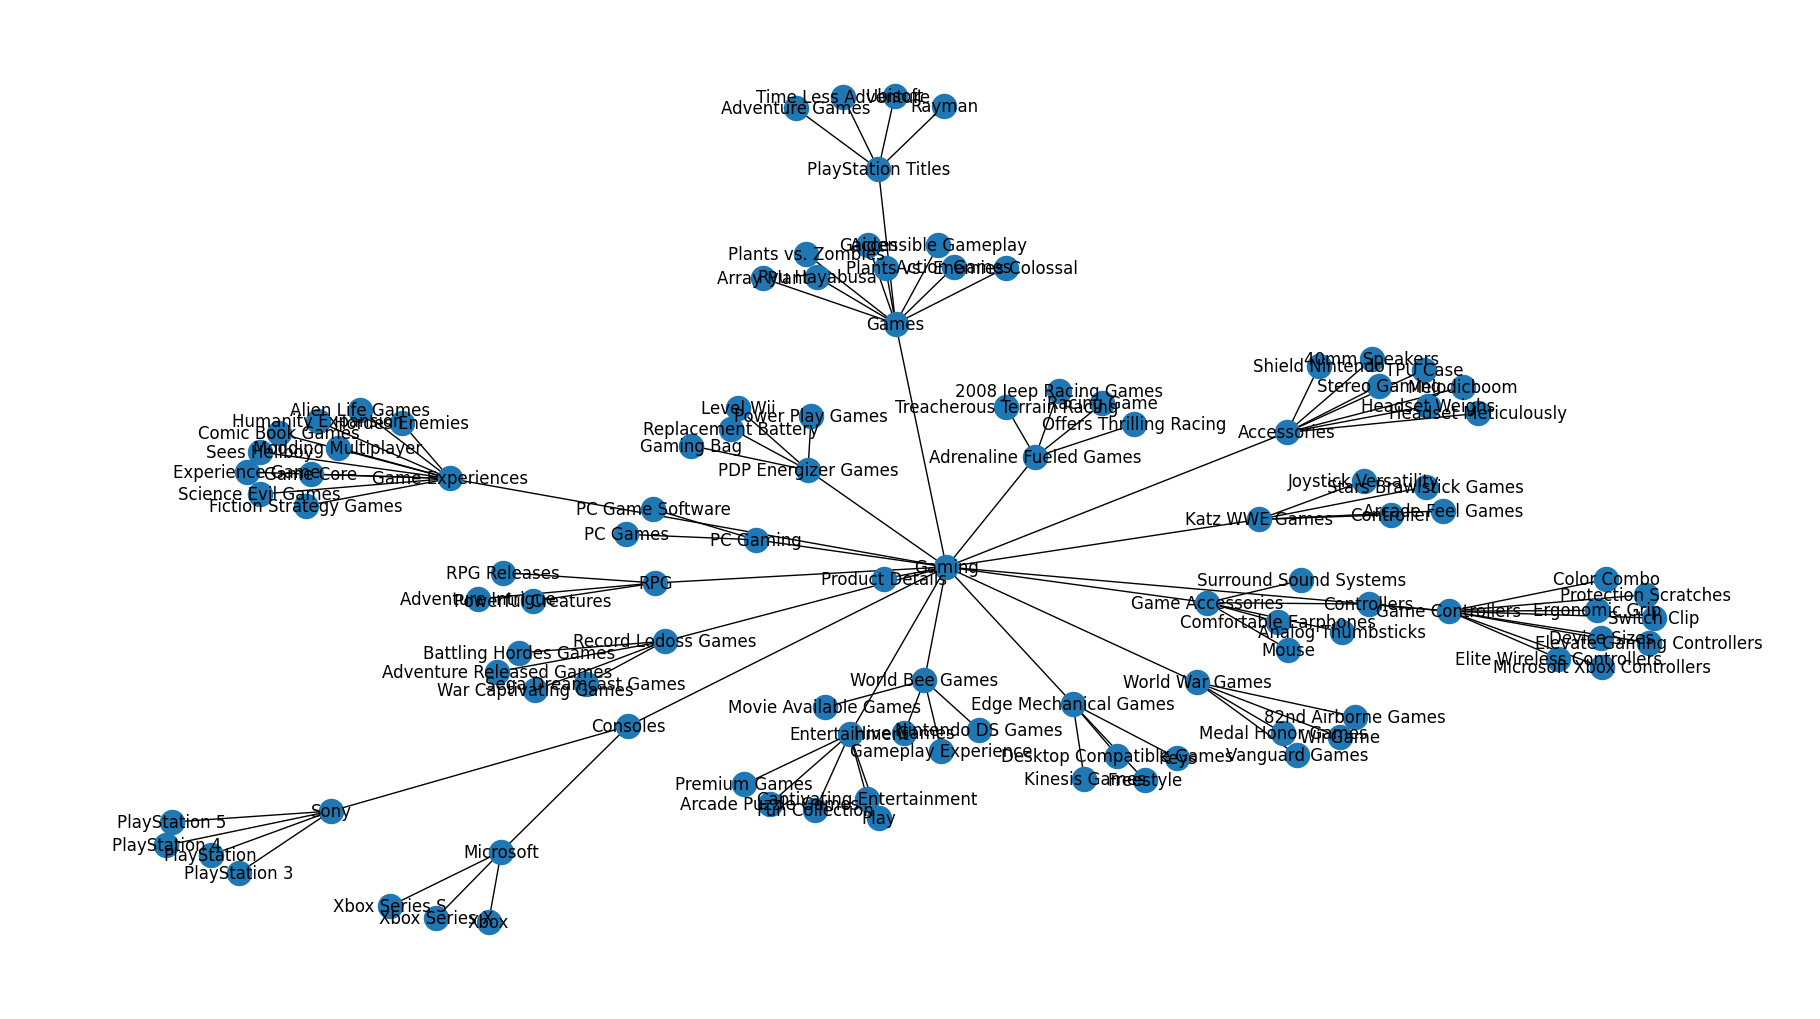

Experiment 5 Taxonomy with selected items (tp from experiment 5)


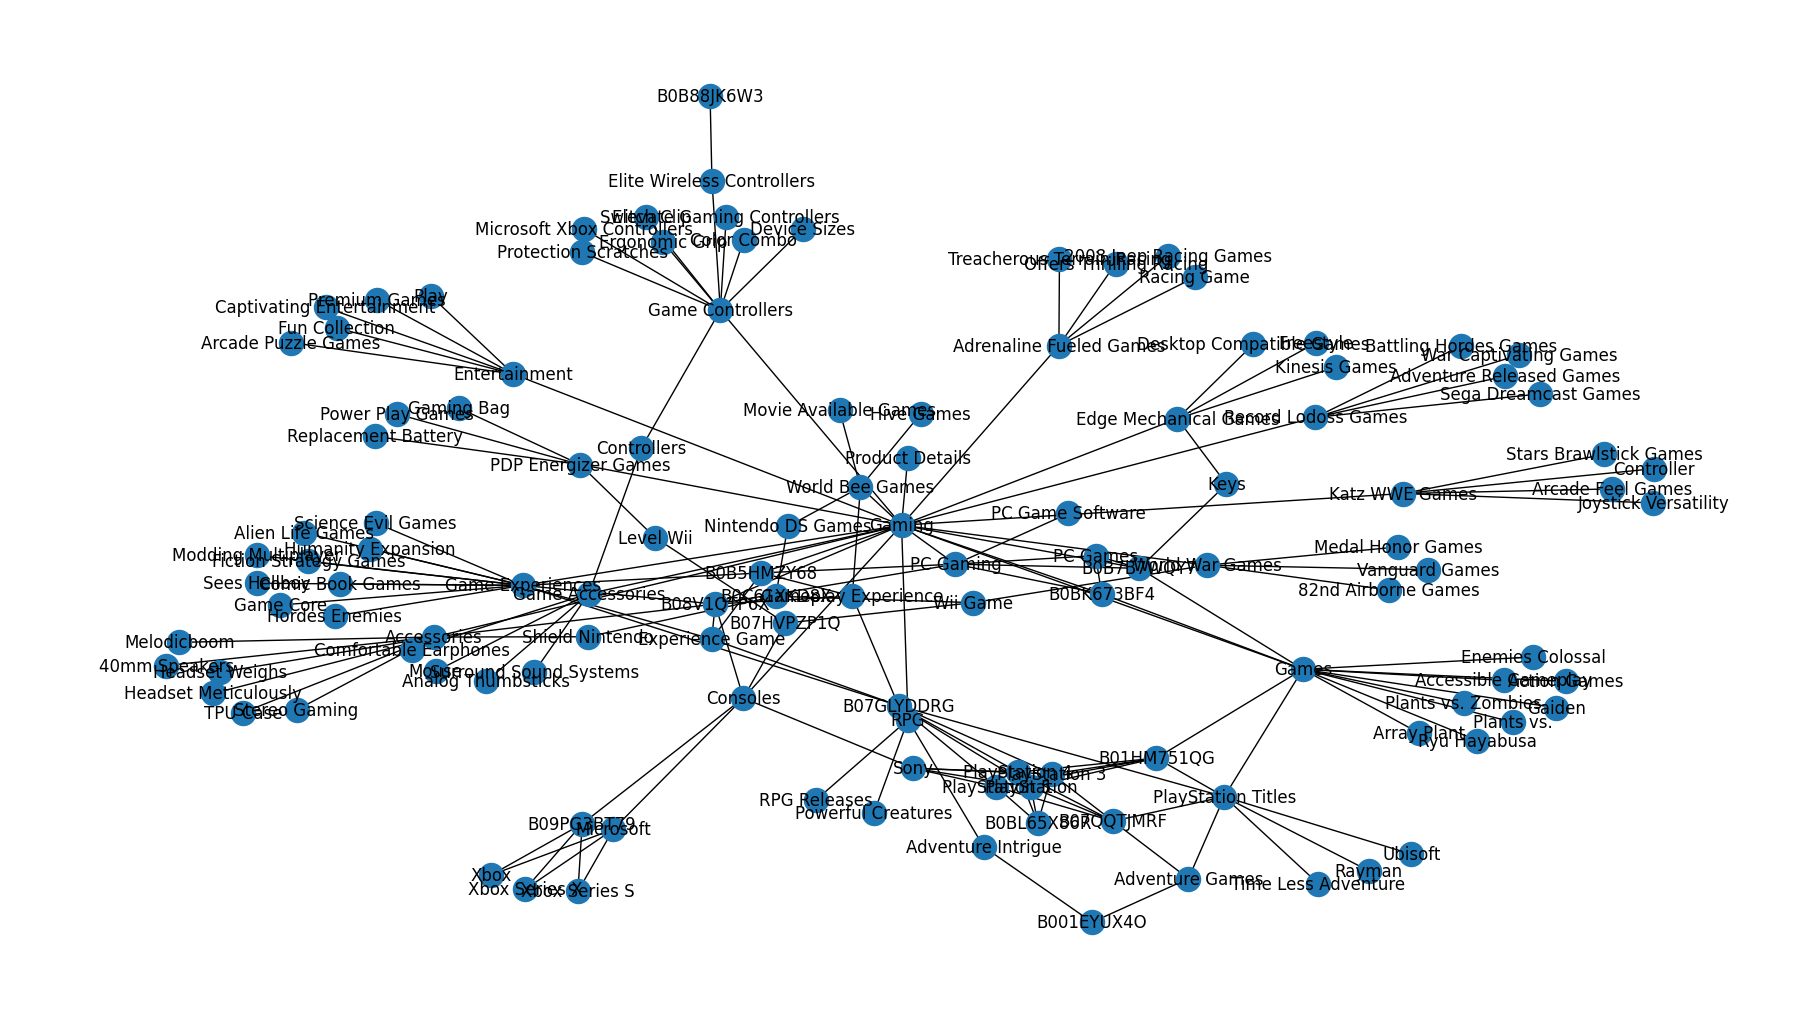

In [153]:
print("Experiment 5 Taxonomy without items")
nx.draw(nx.from_pandas_edgelist(experiment_5_taxonomy_isolated, source='head', target='tail'),with_labels=True)
plt.show()

print("Experiment 5 Taxonomy with selected items (tp from experiment 5)")
nx.draw(g_experiment_5_taxonomy_isolated_with_items, with_labels=True)
plt.show()

 Keep all true positive predictions

**True Positive Analysis Summary**
 
 **Empirical Findings on Batch Size Impact on True Positive Predictions**
 Analysis of users who achieved true positive predictions in Experiment 5 (batch size 5) but not in Experiment 4 reveals no discernible pattern in product descriptions that could explain the performance differential. The absence of systematic semantic patterns suggests that the improvement in true positive predictions cannot be attributed to specific product category characteristics or description-based features. The boost comes from items with diverse association hencing general less noisiness
 
 **Graph Structure Implications**
Looking at the Taxonomy without items for experiment 4 and 5 there are multiple patterns. First we observe different taxonomies, because the taxonomy of experiment 5 was generated with a batch size 5 (instead of 20), while for experiment 4 we used an existing taxonomy of expeirment 1 and experimented with different linking threshholds. In connection to that its visible that the taxonomy for batch size 5 is fine-granular compared to the other one. 
Additionally its observable that more selected items for tp prediciton in test set are connected to the taxomomy for experiment 5 compared to experiment 4. A reason for this could be that the smaller batch size with a lower context window helps the llm to more thorughly generated the taxonomy. Due to this the taxonomy gets fine-granular. This depth visibly supports more keywords have a cosine similarity which is higher than the threshholds. While not having a quantitative proof this cherry picking illustrates that a smaller batch size (without semantically drifting) likely grants a more covered taxonomy. 

 
**Performance Enhancement Mechanism**
The observed improvement in true positive predictions appears to be driven by enhanced graph quality rather than specific structural changes, indicating that batch size optimization primarily affects the overall signal-to-noise ratio in the recommendation graph, thereby boosting ranking accuracy in the critical top-20 prediction window.

## **Summary**
Empirical Analysis of Batch Size Impact on Taxonomy Generation and Recommendation Performance

Taxonomy Structure Analysis
- Batch size 5 demonstrates superior semantic coherence
     - Likely Exhibits enhanced taxonomic coverage
     - Yields more granular hierarchical relationships

 Recommendation Performance Metrics
 - Comparative analysis reveals:
     - NDCG@20: Comparable performance between batch sizes 5 and 15, with both exceeding baseline at 3 and 6 hops
     - Recall@20: Superior performance exclusively with batch size 5 at 3 and 6 hops
     - Optimal batch size 5 demonstrates enhanced ranking metric performance and user pattern recognition
 - Significant improvement in precision of top-20 item ranking
 - Mitigation of popularity bias in recommendation distribution